# **Pengelompokkan Bunga Iris | K - Means Clustering**

Model klustering bunga iris pada kelompok tertentu menggunakan algoritma K - Means Clustering.

## 1. Data Understanding

### 1.1 Import Library

In [311]:
# Impor pustaka yang diperlukan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tkinter as tk

from tkinter import messagebox
from tkinter import *

### 1.2 Import Dataset

In [312]:
# Impor dataset 'Iris.csv'
iris = pd.read_csv('Iris.csv')

### 1.3 Data Profilling

In [313]:
# tampilkan 5 baris teratas dataset
print('\n5 baris teratas:')
iris.head()


5 baris teratas:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [314]:
# Tampilkan informasi dataset
print('\nInformasi dataset:')
iris.info()


Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [315]:
# Tampilkan dimensi dataset
print('\nDimensi dataset:')
print('Jumlah baris:', iris.shape[0])
print('Jumlah kolom:', iris.shape[1])


Dimensi dataset:
Jumlah baris: 150
Jumlah kolom: 6


In [316]:
# Tampilakan jumlah niiai unik per fitur
print('\nJumlah nilai unik per fitur:')
iris.nunique()


Jumlah nilai unik per fitur:


Id               150
SepalLengthCm     35
SepalWidthCm      23
PetalLengthCm     43
PetalWidthCm      22
Species            3
dtype: int64

In [317]:
# Hapus fitur 'Id'
iris = iris.drop('Id', axis=1)

# Tanpilkan informasi dataset setelah fitur 'Id' dihapus 
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [318]:
# Fungis cek nilai unik per fitur
def unique_values(features_name):
    print(f'\nNilai unik fitur {features_name}:')
    print('Jumlah nilai unik:', iris[features_name].nunique())
    print('\nNilai unik:', iris[features_name].unique().tolist())

In [319]:
# Panggil fungsi nilai unik 
unique_values('Species')


Nilai unik fitur Species:
Jumlah nilai unik: 3

Nilai unik: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [320]:
# Tampilkan total missing value
print('\nTotal missing value:', iris.isnull().sum().sum())


Total missing value: 0


In [321]:
# Tampilkan total data duplikat
print('\nTotal data duplikat:', iris.duplicated().sum())


Total data duplikat: 3


In [322]:
# Tampilkan baris dengan data duplikat
print('\nBaris dengan data duplikat:')
duplicate_rows = iris[iris.duplicated(keep=False)]
duplicate_rows


Baris dengan data duplikat:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
9,4.9,3.1,1.5,0.1,Iris-setosa
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
101,5.8,2.7,5.1,1.9,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica


## 2. Exploratory Data Analysis (EDA)


### 2.1 Multivariate Analysis 

In [323]:
# Pisah fitur numerik dan kategorikal
num_cols = iris.select_dtypes(include=['int64', 'float64'])
cat_cols = iris.select_dtypes(include=['object', 'category'])


/tmp/ipykernel_52262/1925452131.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = iris.select_dtypes(include=['object', 'category'])


In [324]:
# Tampilkan statistik fitur dataset
print('\nStatistik fitur numerik dataset:')
num_cols.describe()


Statistik fitur numerik dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [325]:
# Tampilkan statistik fitur kategori dataset
print('\nStatistik dataset fitur kategori:')
cat_cols.describe()


Statistik dataset fitur kategori:


,Species
count,150
unique,3
top,Iris-setosa
freq,50


In [326]:
# Cek perbandingan quantile 75 denga nilai max, serta perbandingan median dengan quantile 75
print('\nPerbandingan selisih median, kuantil 75%, dan nilai maksimal:')
for col in num_cols:
    quantile_75 = iris[col].quantile(0.75)
    median = iris[col].quantile(0.50)
    max_values = iris[col].max()

    selisih1 = quantile_75 - median
    selisih2 = max_values - quantile_75

    print(f'\nFitur {col}:')
    print(f'Selisih antara median dengan kuantil 75: {selisih1:.2f}')
    print(f'Selisih antara kuantil 75% dengan nilai maksimal {selisih2:.2f}')


Perbandingan selisih median, kuantil 75%, dan nilai maksimal:

Fitur SepalLengthCm:
Selisih antara median dengan kuantil 75: 0.60
Selisih antara kuantil 75% dengan nilai maksimal 1.50

Fitur SepalWidthCm:
Selisih antara median dengan kuantil 75: 0.30
Selisih antara kuantil 75% dengan nilai maksimal 1.10

Fitur PetalLengthCm:
Selisih antara median dengan kuantil 75: 0.75
Selisih antara kuantil 75% dengan nilai maksimal 1.80

Fitur PetalWidthCm:
Selisih antara median dengan kuantil 75: 0.50
Selisih antara kuantil 75% dengan nilai maksimal 0.70


Tidak ada selisih nilai yang ekstrim untuk kuantil 75% dengan nilai maksimum. Serta, perbandingan selisih1 dan selisih2 juga tidak ekstrim. Jadi, ada kemungkinan nilai dari per fitur cenderung tidak ada outlier.

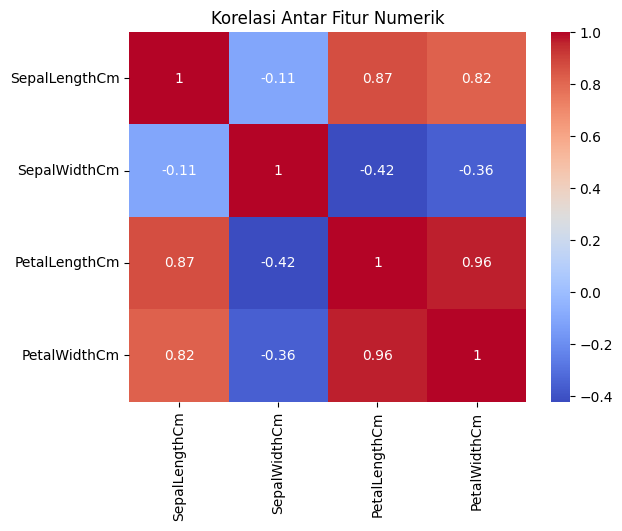

In [327]:
# Korelasi fitur numerik
correlation = num_cols.corr()

# Visualisasi heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

Terdapat beberapa fitur yang berkorelasi tinggi dengan fitur lainnya. Model K-means sensitif terhadap multikolinearitas. Karena, k means bekerja dengan menghitung jarak encludian. Jika ada fitur yang mirip, ini membuat model condong ke arah fitur yang berkorelasi tinggi. Sehingga, mengabaikan fitur yang lain.

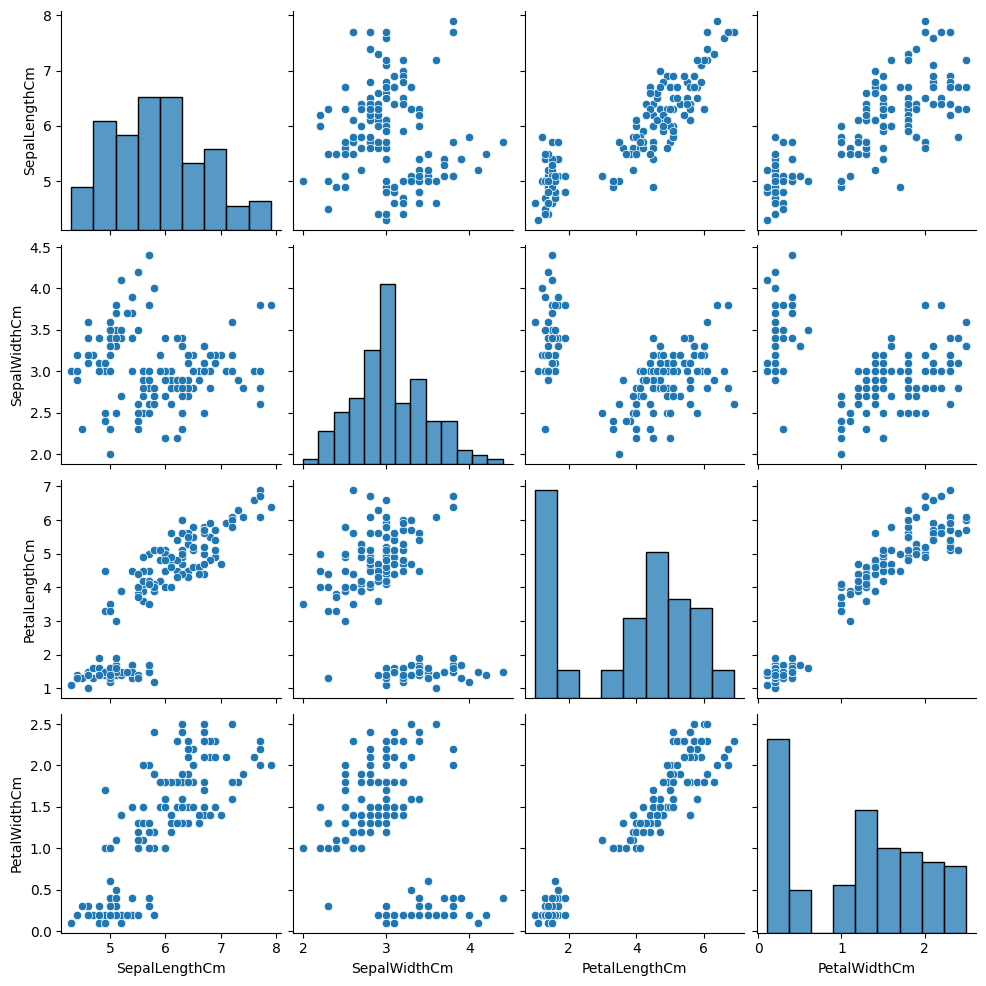

In [328]:
# Visualisasi pairplot
sns.pairplot(num_cols)
plt.show()

Pada kumpulan grafik scatter plot diatas, ternyata, ada beberapa fitur yang pembagian pembagian kelompok yang jelas, ada juga yang cukup merata yakni pada fitur 'SepalWidthCm'. Sedangkan, pada distribusi nilai per fitur cukup merata.

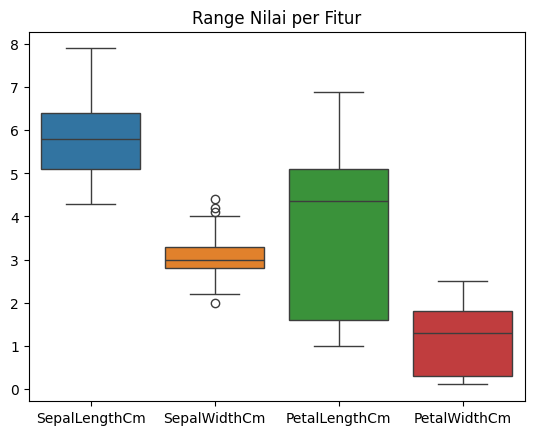

In [329]:
# Visualisasi graifik boxplot
sns.boxplot(iris)
plt.title('Range Nilai per Fitur')
plt.show()

Terdapat beberapa nilai yang diluar range pada fitur 'SepalWidthCm'. Karena K - Means sensitif terhadap outlier, kami akan tangani dengan metode clip.

### 2.2 Univariate Analysis

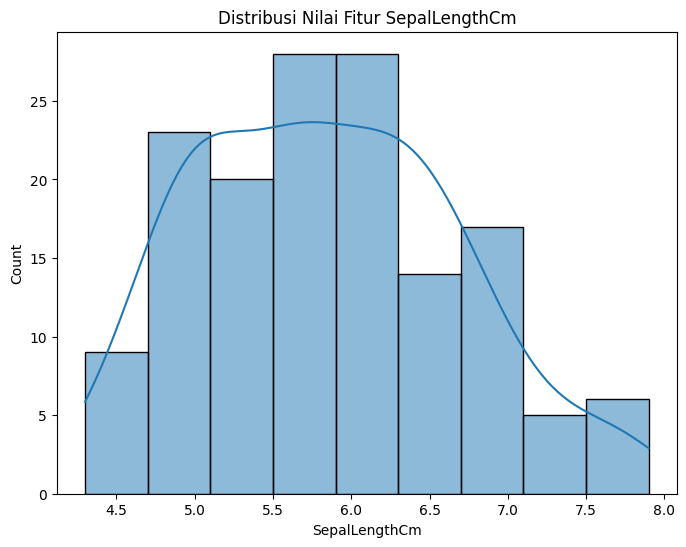

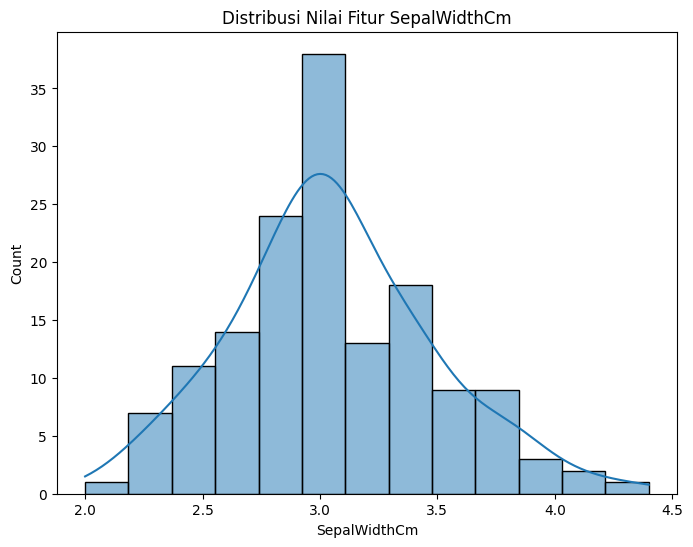

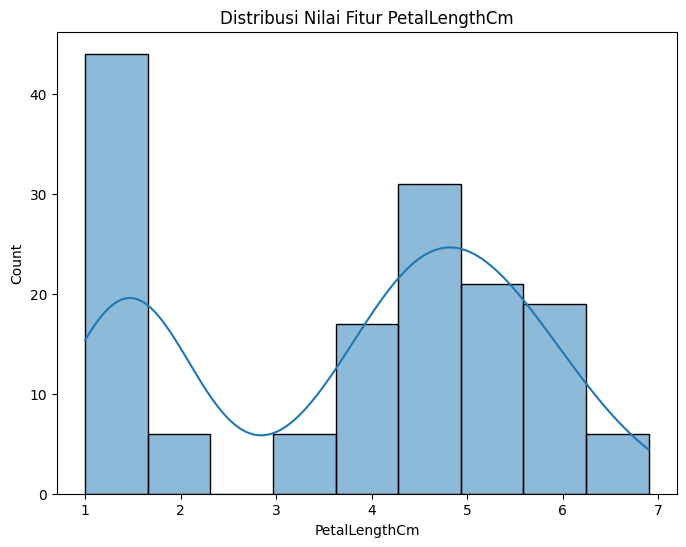

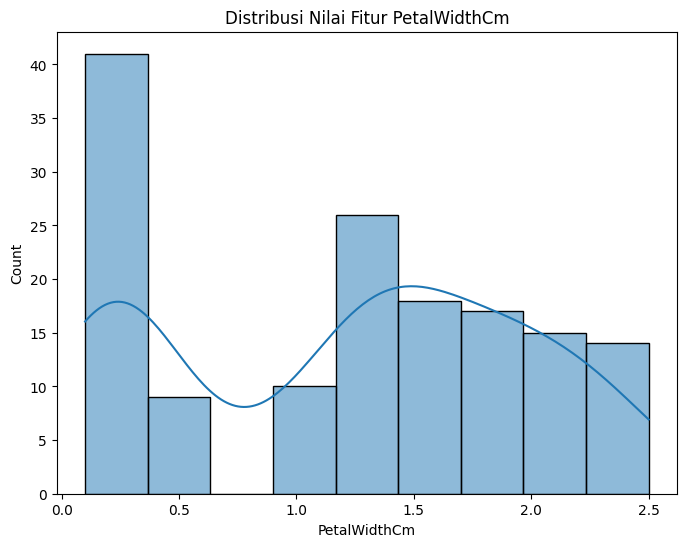

In [330]:
# Distribusi fitur numerik
for col in num_cols:
    plt.figure(figsize=(8,6))
    sns.histplot(data=iris, x=iris[col], kde=True)
    plt.title(f'Distribusi Nilai Fitur {col}')
    plt.show()

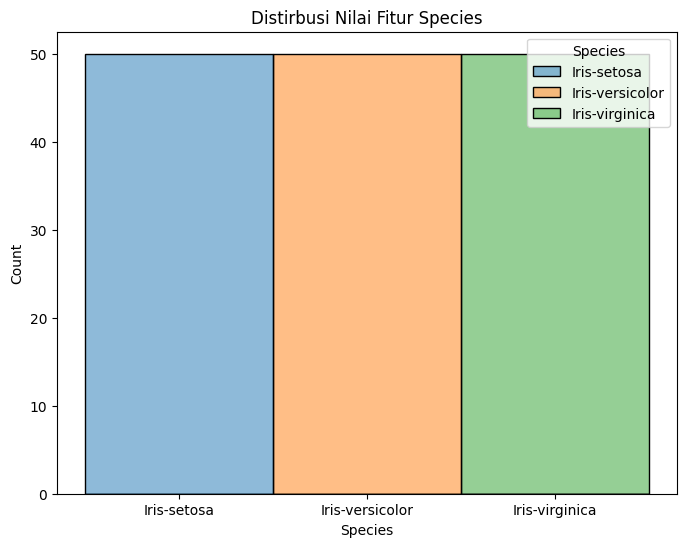

In [331]:
# Visualisasi distribusi fitur kategori
plt.figure(figsize=(8, 6))
sns.histplot(data=iris, x=iris['Species'], hue=iris['Species'])
plt.title('Distirbusi Nilai Fitur Species')
plt.show()

Distribusi nilai pada fitur 'Species' menyebar secara merata (balance).

### 2.3 Bivariate Analysis

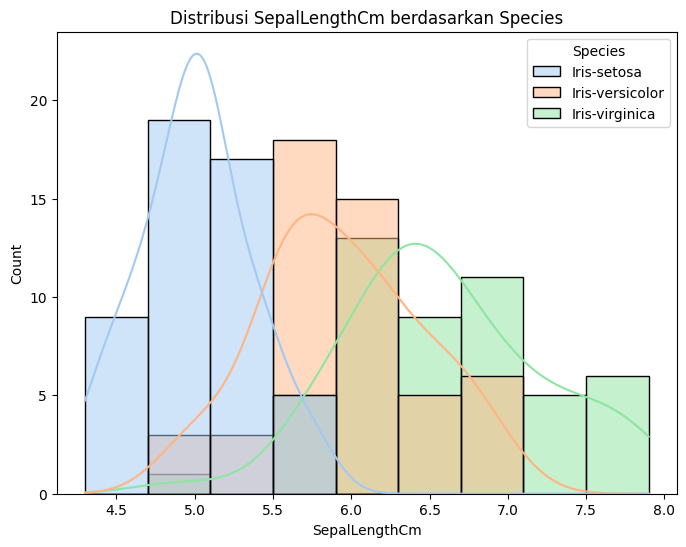

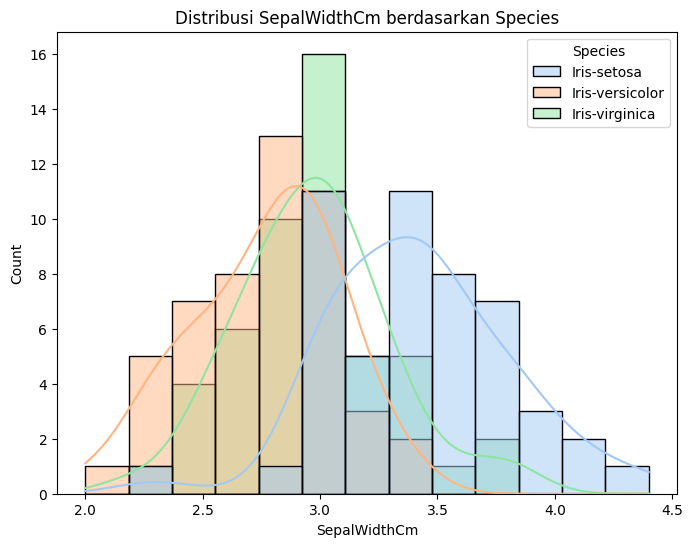

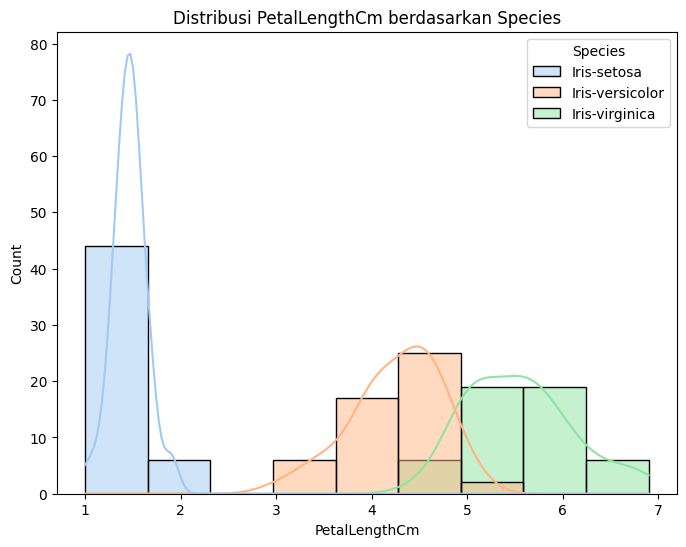

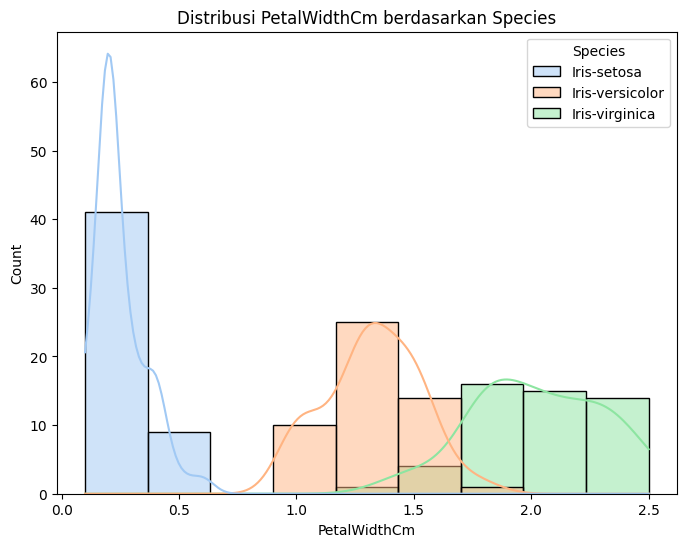

In [332]:
# Visualisasi grouby
for col in iris.select_dtypes(include=['int64', 'float64']):
    plt.figure(figsize=(8, 6))
    sns.histplot(data=iris, x=col, hue=iris['Species'], palette='pastel', kde=True)
    plt.title(f'Distribusi {col} berdasarkan Species')
    plt.show()

- Visualisasi PetalWidthCm,PetalLeghtCm vs Species:
1. Spesies Iris Setosa cenderung memiliki lebar dan panjang mahkota terkecil dari 2 species lainnya.
2. Spesies Iris Versicolor cenderung memiliki ukuran lebar dan panjang mahkota yang lebih besar dari Iris setosa. Serta ada overlap sedikit dengan iris virginica, Sedangkan,
3. iris Virginica cenderung memiliki nilai lebar dan panjang yang lebih besar dari 2 species sebelumnya. 

Untuk fitur lainnya, penyebaran nilainya cukup merata dan bertumpuk. Sehingga tidak terlalu informatif. Ini, bisa dipertimbangkan nanti untuk menggunakan PCA.

## 3. Data Preprocessing

### 3.1 Handling Data Duplikat

In [333]:
# tangain dengan menghapus baris pertama data duplikat
iris = iris.drop_duplicates(keep='first')

print('\nTotal data duplikat setelah ditangani:', iris.duplicated().sum())


Total data duplikat setelah ditangani: 0


### 3.2 Handling Nilai Diluar Range 

In [334]:
# Handling Nilai diluar range
Q1 = iris['SepalWidthCm'].quantile(0.25)
Q3 = iris['SepalWidthCm'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = iris[(iris['SepalWidthCm'] < lower_bound) | (iris['SepalWidthCm'] > upper_bound)]
print(f'Jumlah nilai diluar range pada fitur SepalWidthCm: {outliers.shape[0]}')


iris['SepalWidthCm'] = iris['SepalWidthCm'].clip(lower=lower_bound, upper=upper_bound)

Jumlah nilai diluar range pada fitur SepalWidthCm: 4


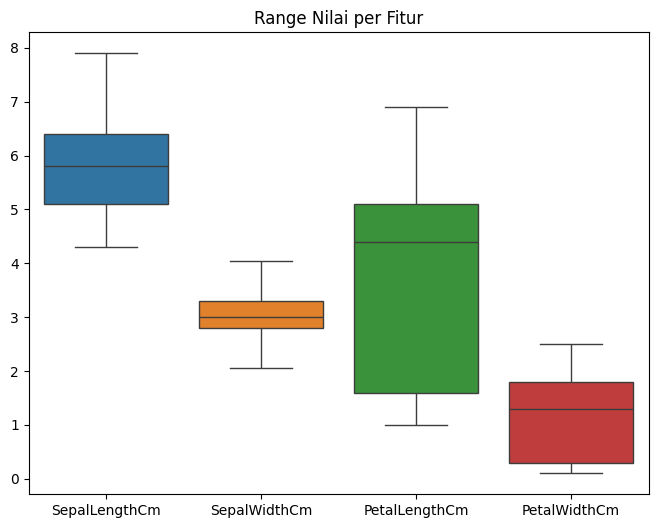

In [335]:
# Visualisasi boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(iris)
plt.title('Range Nilai per Fitur')
plt.show()

### 3.3 Encoding Fitur Kategorikal (Species)

In [336]:
# Nilai unik fitur 'Species'
iris['Species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Encoding menggunkan teknik mapping. Dimana:
- Iris-setosa  -> 0
- Iris-versicolor -> 1
- Iris-virginica  -> 2

In [337]:
# Encoding menggunkan metode mapping
iris['Species'] = iris['Species'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})

In [338]:
# Tampilkan nilai unik 'Species' setelah encoding
print('\nNilai unik fitur Species setelah encoding:', iris['Species'].unique())


Nilai unik fitur Species setelah encoding: [0 1 2]


### 3.3 PCA

In [339]:
# Fungsi PCA
def pca_manual(X, n_components=2):
    # LANGKAH 1: Covariance Matrix
    # rowvar=False artinya: kolom kita adalah fitur (bukan baris)
    cov_matrix = np.cov(X, rowvar=False)

    # LANGKAH 2: Eigen Values & Vectors (Jantungnya PCA)
    values, vectors = np.linalg.eig(cov_matrix)

    # LANGKAH 3: Urutkan variansi dari yang terbesar (ambil yang terbesar)
    sorted_index = np.argsort(values)[::-1]  # [::-1] urut besar ke kecil
    sorted_vectors = vectors[:, sorted_index]

    # LANGKAH 4: Ambil 2 vektor teratas & Proyeksikan
    subset_vectors = sorted_vectors[:, :n_components]
    X_reduced = np.dot(X, subset_vectors)

    return X_reduced, sorted_vectors

In [340]:
# Panggil fungsi PCA
X_pca, sorted_vectors = pca_manual(num_cols)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

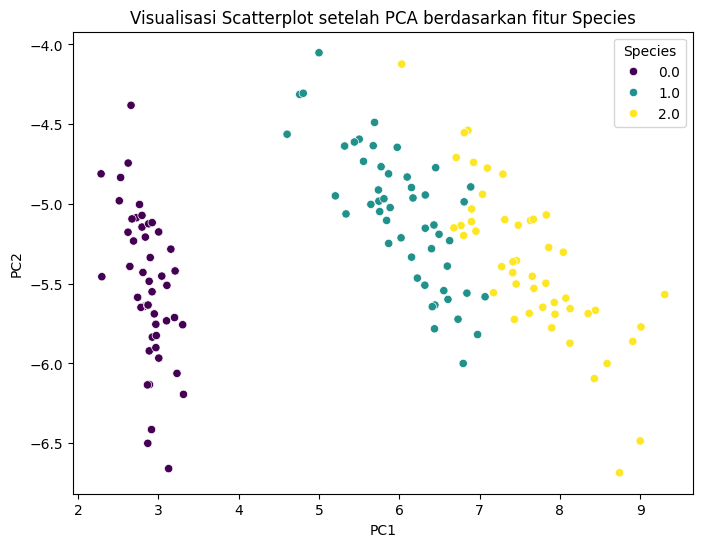

In [341]:
# Visualisasi scatterplot setelah pca 
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue=iris['Species'],
    palette='viridis'
)
plt.title('Visualisasi Scatterplot setelah PCA berdasarkan fitur Species')
plt.show()


In [342]:
feature = iris.select_dtypes(include='number')

# normalisasi
# data_scaled = (feature - feature.min(axis=0)) / (feature.max(axis=0) - feature.min(axis=0))

# standarisasi
data_scaled = (feature - feature.mean(axis=0)) / (feature.std(axis=0) + 1e-9)

In [343]:
def kmean(data, k, p=2, iteration=200):
    np.random.seed(42)
    X = data.values
    random_idx = np.random.choice(len(X), k, replace=False)
    centroid = X[random_idx]

    for i in range(iteration):
        diff = np.abs(X[:, np.newaxis] - centroid)

        distance = np.sum(diff**p, axis=2)**(1/p)

        label = np.argmin(distance, axis=1)

        new_centroid = np.array([X[label == i].mean(axis=0) for i in range(k)])
        if np.linalg.norm(new_centroid - centroid) < 1e-4:
            break
        centroid = new_centroid
    return label, centroid

In [344]:
def wcss(data, k, p=2):
    cluster, centroid = kmean(data_scaled, k, p=2)
    X = data.values

    diff = np.abs(X[:, np.newaxis] - centroid)
    distance = np.sum(diff**p, axis=1)**(1/p)
    min_distance = np.argmin(distance, axis=1)

    if p == 2:
        error = np.sum(min_distance ** 2)
    else:
        error = np.sum(min_distance)
    return error


In [345]:
hasil_wcss = wcss(data_scaled, k=3)
hasil_wcss

np.int64(247)

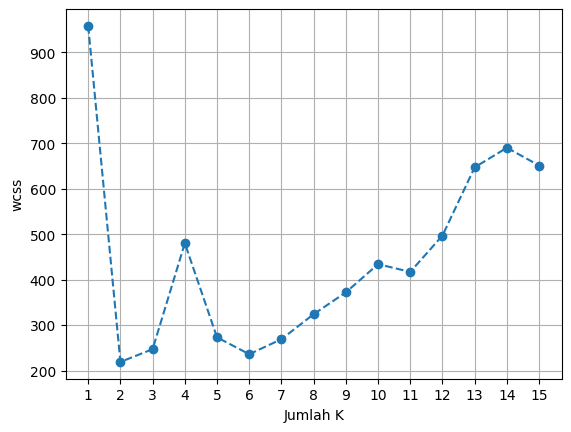

In [346]:
def elbow(data, range_k=range(1,16)):
    wcss_value = []

    for k in range_k:
        hasil_wcss = wcss(data, k)
        wcss_value.append(hasil_wcss)
    plt.plot(range_k, wcss_value, marker='o', linestyle='--')
    plt.xticks((range_k))
    plt.ylabel('wcss')
    plt.xlabel('Jumlah K')
    plt.grid(True)
    plt.show()
elbow(data_scaled)

In [347]:
def shilouette(data, k):
    cluster, centroid = kmean(data, k)
    score = []
    
    for i in range(len(data)):
        ci = cluster[i]

        samecp = data[cluster == ci].to_numpy()
        ai = np.mean(np.linalg.norm(samecp - data.iloc[i].to_numpy(), axis=1))

        distance_other = []
        for j in range(k):
            if j != ci:
                othercp = data[cluster == j].to_numpy()
                bi_temp = np.mean(np.linalg.norm(othercp - data.iloc[i].to_numpy(), axis=1))
                distance_other.append(bi_temp)
        bi = min(distance_other)

        score_i = (bi - ai) / max(bi, ai)
        score.append(score_i)

    avrg_score = np.mean(score)
    
    return avrg_score

In [348]:
hasil_shilouette = shilouette(data_scaled, k=3)
hasil_shilouette

np.float64(0.4903821082902933)

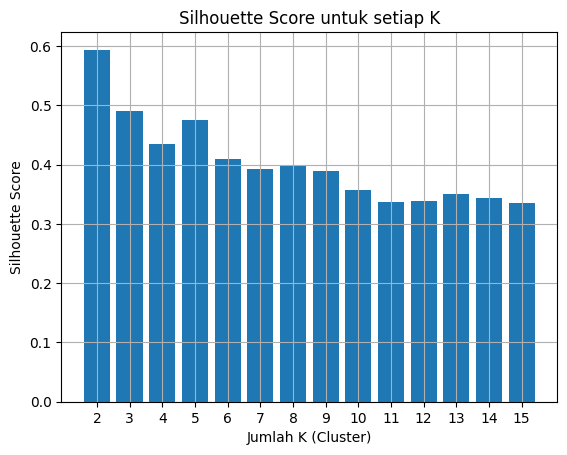

In [349]:

sscore = []
range_k = range(2,16)
for k in range_k:
    score = shilouette(data_scaled ,k)
    sscore.append(score)
plt.bar(range_k, sscore, )
plt.title(f"Silhouette Score untuk setiap K")
plt.xlabel('Jumlah K (Cluster)')
plt.ylabel('Silhouette Score')
plt.xticks(range_k)
plt.grid(True)
plt.show()

In [355]:
cluster,centroid = kmean(df_pca,k=2)

df_pca['cluster'] = cluster
df_pca.head()

,PC1,PC2,cluster
0,2.827136,-5.641331,1
1,2.795952,-5.145167,1
2,2.621524,-5.177378,1
3,2.764906,-5.003599,1
4,2.782750,-5.648648,1


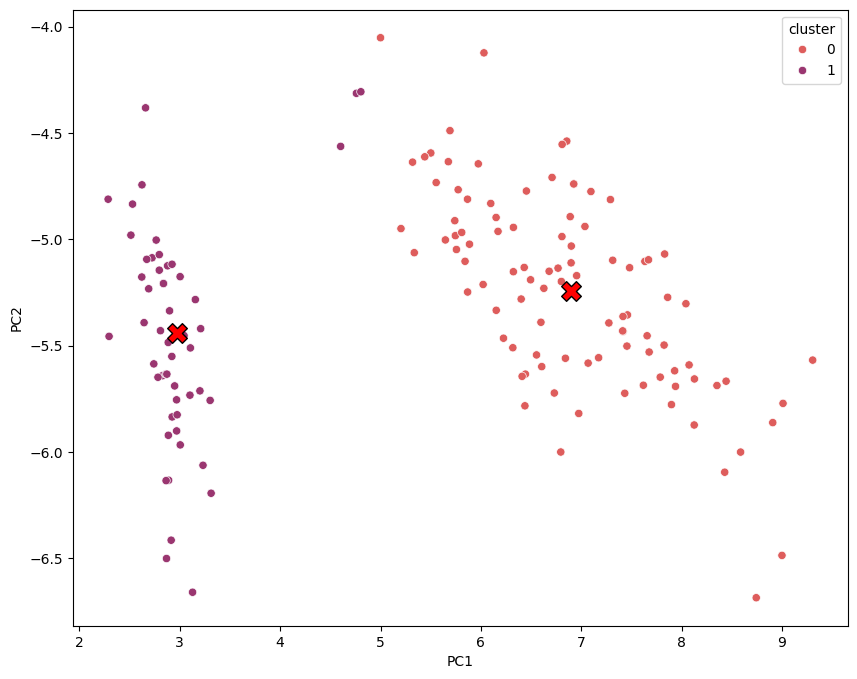

In [356]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='flare')
plt.scatter(
    centroid[:, 0], centroid[:, 1],
    c='red', marker='X', s=200,
    label='Centroids',
    edgecolor='black'
)
plt.show()

In [357]:
cluster, centroid = kmean(data_scaled, k=2)

data_scaled['cluster'] = cluster
data_scaled.sample(15)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,cluster
33,-0.429939,2.340011,-1.353111,-1.331149,-1.235237,1
105,2.102928,-0.122865,1.602928,1.175863,1.218544,0
20,-0.550552,0.815374,-1.182570,-1.331149,-1.235237,1
50,1.379252,0.346255,0.522837,0.252227,-0.008346,0
103,0.534963,-0.357424,1.034459,0.780019,1.218544,0
9,-1.153616,0.111695,-1.296264,-1.463097,-1.235237,1
14,-0.068101,2.222732,-1.466805,-1.331149,-1.235237,1
13,-1.877292,-0.122865,-1.523652,-1.463097,-1.235237,1
149,0.052512,-0.122865,0.750224,0.780019,1.218544,0
35,-1.033003,0.346255,-1.466805,-1.331149,-1.235237,1


In [358]:
data_scaled.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,cluster
0,-0.912390,1.049934,-1.353111,-1.331149,-1.235237,1
1,-1.153616,-0.122865,-1.353111,-1.331149,-1.235237,1
2,-1.394841,0.346255,-1.409958,-1.331149,-1.235237,1
3,-1.515454,0.111695,-1.296264,-1.331149,-1.235237,1
4,-1.033003,1.284493,-1.353111,-1.331149,-1.235237,1


In [362]:
import tkinter as tk
from tkinter import *

kolom_fitur = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

std_mean = iris[kolom_fitur].mean(axis=0).to_numpy()
std_std = iris[kolom_fitur].std(axis=0).to_numpy()

pca_vector = sorted_vectors[:, 2]
jarak_centroids = centroid

def prediksi():
    sepallen = float(input_sepallen.get())
    sepalwid = float(input_sepalwid.get())
    petallen = float(input_petallen.get())
    petalwid = float(input_petalwid.get())
    
    X_input = np.array([sepallen, sepalwid, petallen, petalwid])
    X_scaled = (X_input - std_mean) / std_std
    X_pca = np.dot(X_scaled, pca_vector)
    jarak = np.linalg.norm(X_pca - jarak_centroids, axis=1)
    hasil_cluster = np.argmin(jarak)
    if hasil_cluster == 0:
        teks_hasil = "Iris Virginica"
        warna = "#6145ff"
    elif hasil_cluster == 1:
        teks_hasil = "Iris Versicolor"
        warna = "#892aa1"
    elif hasil_cluster == 2:
        teks_hasil = "Iris Setosa"
        warna = "#7D1FEF"
    else:
        teks_hasil = "Input Angka Yang Valid"
        warna ='red'
    hasil_predict.config(text=f"{teks_hasil}", fg=f"{warna}")
    

root = tk.Tk()
root.title("K-Means++ Clustering")
root.config(bg="#762aac")
root.geometry("400x500")

Header = Frame(root, bg="#af81cf")
Header.pack(fill=X)
Judul = Label(Header, text="Iris Species Predictor",bg="#af81cf", fg="white", font=("Arial", 18, "bold"))
Judul.pack(pady=(20,10))
Deskripsi = Label(Header, text="K-Means++ Clustering",bg="#af81cf", fg="white", font=("Arial", 12, "bold"))
Deskripsi.pack(pady=(0, 20))

Main = Frame(root, bg="#7b648c")
Main.pack(padx= 30, pady = 30)

Label(Main, text="Panjang Sepal (Cm)", bg="#7b648c", fg="white", font=("Arial", 10, "bold")).pack()
input_sepallen = Entry(Main, width=50)
input_sepallen.pack()

Label(Main, text="Lebar Sepal (Cm)", bg="#7b648c", fg="white", font=("Arial", 10, "bold")).pack()
input_sepalwid = Entry(Main, width=50)
input_sepalwid.pack()

Label(Main, text="Panjang Petal (Cm)", bg="#7b648c", fg="white", font=("Arial", 10, "bold")).pack()
input_petallen = Entry(Main, width=50)
input_petallen.pack()

Label(Main, text="Lebar Petal (Cm)", bg="#7b648c", fg="white", font=("Arial", 10, "bold")).pack()
input_petalwid = Entry(Main, width=50)
input_petalwid.pack()

Hasil = Frame(root, bg="#7b648c")
Hasil.pack()
btn_predict = Button(Hasil, text="Prediksi Spesies", command=prediksi, bg="#af81cf", fg="white")
btn_predict.pack()
hasil_predict = Label(text="-", font=("Arial", 10, "bold"), fg="black")
hasil_predict.pack(pady=10)

root.mainloop()

In [359]:
kolom_fitur = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
feature = data_scaled.drop(['Species', 'cluster'], axis=1)

std_mean = iris[kolom_fitur].mean(axis=0).to_numpy()
std_std = iris[kolom_fitur].std(axis=0).to_numpy()

pca_vector = sorted_vectors[:, 3]
_, centroid = kmean(df_pca, k=3)
jarak_centroids = centroid

X_pca = np.dot(feature, pca_vector)
jarak = np.linalg.norm(X_pca[:, np.newaxis] - jarak_centroids, axis=2)    

print(f"Hasil Proyeksi PCA: {X_pca}")
print(f"Jarak ke tiap centroid: {jarak}") # Lihat mana yang paling kecil
    
hasil_cluster = np.argmin(jarak)
def prediksi():
    sepallen = float(input_sepallen.get())
    sepalwid = float(input_sepalwid.get())
    petallen = float(input_petallen.get())
    petalwid = float(input_petalwid.get())
    
    X_input = np.array([sepallen, sepalwid, petallen, petalwid])
    X_scaled = (X_input - std_mean) / std_std
    X_pca = np.dot(X_scaled, pca_vector)
    jarak = np.linalg.norm(X_pca - jarak_centroids, axis=1)
    hasil_cluster = np.argmin(jarak)
    if hasil_cluster == 0:
        teks_hasil = "Iris Virginica"
        warna = "#6145ff"
    elif hasil_cluster == 1:
        teks_hasil = "Iris Versicolor"
        warna = "#892aa1"
    elif hasil_cluster == 2:
        teks_hasil = "Iris Setosa"
        warna = "#7D1FEF"
    else:
        teks_hasil = "Input Angka Yang Valid"
        warna ='red'
    hasil_predict.config(text=f"{teks_hasil}", fg=f"{warna}")
    

root = tk.Tk()
root.title("K-Means++ Clustering")
root.config(bg="#762aac")
root.geometry("400x500")

Header = Frame(root, bg="#af81cf")
Header.pack(fill=X)
Judul = Label(Header, text="Iris Species Predictor",bg="#af81cf", fg="white", font=("Arial", 18, "bold"))
Judul.pack(pady=(20,10))
Deskripsi = Label(Header, text="K-Means++ Clustering",bg="#af81cf", fg="white", font=("Arial", 12, "bold"))
Deskripsi.pack(pady=(0, 20))

Main = Frame(root, bg="#7b648c")
Main.pack(padx= 30, pady = 30)

Label(Main, text="Panjang Sepal (Cm)", bg="#7b648c", fg="white", font=("Arial", 10, "bold")).pack()
input_sepallen = Entry(Main, width=50)
input_sepallen.pack()

Label(Main, text="Lebar Sepal (Cm)", bg="#7b648c", fg="white", font=("Arial", 10, "bold")).pack()
input_sepalwid = Entry(Main, width=50)
input_sepalwid.pack()

Label(Main, text="Panjang Petal (Cm)", bg="#7b648c", fg="white", font=("Arial", 10, "bold")).pack()
input_petallen = Entry(Main, width=50)
input_petallen.pack()

Label(Main, text="Lebar Petal (Cm)", bg="#7b648c", fg="white", font=("Arial", 10, "bold")).pack()
input_petalwid = Entry(Main, width=50)
input_petalwid.pack()

Hasil = Frame(root, bg="#7b648c")
Hasil.pack()
btn_predict = Button(Hasil, text="Prediksi Spesies", command=prediksi, bg="#af81cf", fg="white")
btn_predict.pack()
hasil_predict = Label(text="-", font=("Arial", 10, "bold"), fg="black")
hasil_predict.pack(pady=10)

root.mainloop()

ValueError: operands could not be broadcast together with shapes (147,1) (3,3) 

# dsakl;


In [ ]:
# import tkinter as tk
# from tkinter import *

# kolom_fitur = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

# # Standarisasi
# std_mean = iris[kolom_fitur].mean(axis=0).to_numpy()
# std_std = iris[kolom_fitur].std(axis=0).to_numpy()

# # Ambil 2 Vektor (PCA)
# vector_pca = sorted_vectors[:, :2]

# # Ambil Centroid
# _, centroid = kmean(iris, k=2)
# centroids_jarak = centroid[:, :5]

# def prediksi():
#         cl = float(input_cl.get())
#         cd = float(input_cd.get())
#         fl = float(input_fl.get())
#         bm = float(input_bm.get())
#         bs = float(input_bs.get())

#         # B. Jadikan Array Numpy
#         data_input = np.array([cl, cd, fl, bm, bs])

#         # C. Standarisasi (Rumus Z-Score)
#         data_scaled = (data_input - std_mean) / std_std

#         # D. Proyeksi PCA (Dot Product)
#         data_pca = np.dot(data_scaled, vector_pca)

#         # E. Hitung Jarak ke Semua Centroid (Euclidean Distance)
#         jarak = np.linalg.norm(centroids_jarak - data_scaled, axis=1)

#         # F. Ambil yang Paling Dekat (Min)
#         cluster_terpilih = np.argmin(jarak)

#         # G. Tampilkan Hasil
#         if cluster_terpilih == 0:
#             teks_hasil = "Kluster 0"
#         elif cluster_terpilih == 1:
#             teks_hasil = "Kluster 1"
#         else:
#             teks_hasil = "Unkown"
#         hasil_prediksi.config(text=f"{teks_hasil}")


# # GUI UTAMA
# root = tk.Tk()
# root.title("K-Means Clustering - Penguin Species Prediction")
# root.geometry("500x600")
# root.config(bg="#1e3d59")

# # Header
# header = Frame(root, bg="#f5f0e1")
# header.pack(fill=X)
# Label(header, text="Penguin Predictor", font=('Arial', 18, 'bold',), fg='#1e3d59', bg="#f5f0e1").pack(pady=5)
# Label(header, text="K-Means Clustering + PCA", font=('Arial', 12), fg='#1e3d59', bg="#f5f0e1").pack(pady=(0,5))

# main = Frame(root, bg="#1e3d59")
# main.pack(pady=20)

# aturan = Frame(main, bg="#1e3d59")
# aturan.pack()

# Label(aturan, text="1. Culmen Length (mm) / Panjang Paruh", font=('Arial', 10, 'bold'), fg='white', bg="#1e3d59").pack(pady=(10,0))
# input_cl = Entry(aturan, width=30)
# input_cl.pack()

# Label(aturan, text="2. Culmen Depth (mm) / Tebal Paruh", font=('Arial', 10, 'bold'), fg='white', bg="#1e3d59").pack(pady=(10,0))
# input_cd = Entry(aturan, width=30)
# input_cd.pack()

# Label(aturan, text="3. Flipper Length (mm) / Panjang Sirip", font=('Arial', 10, 'bold'), fg='white', bg="#1e3d59").pack(pady=(10,0))
# input_fl = Entry(aturan, width=30)
# input_fl.pack()

# Label(aturan, text="4. Body Mass (g) / Berat Badan", font=('Arial', 10, 'bold'), fg='white', bg="#1e3d59").pack(pady=(10,0))
# input_bm = Entry(aturan, width=30)
# input_bm.pack()

# Label(aturan, text="4. Body Mass (g) / Berat Badan", font=('Arial', 10, 'bold'), fg='white', bg="#1e3d59").pack(pady=(10,0))
# input_bs = Entry(aturan, width=30)
# input_bs.pack()

# hasil = Frame(root, bg="#1e3d59")
# hasil.pack(pady=30)

# button = Button(hasil, text='PREDIKSI SPESIES', font=('Arial', 11, 'bold'), bg='#ff6e40', fg='white', command=prediksi)
# button.pack(ipadx=10, ipady=5)

# Label(hasil, text="Hasil Prediksi:", font=('Arial', 10), fg='white', bg="#1e3d59").pack(pady=(20,5))
# hasil_prediksi = Label(hasil, text='-', font=('Arial', 16, 'bold'), fg='#ffc13b', bg="#1e3d59")
# hasil_prediksi.pack()

# root.mainloop()

In [ ]:
# feature = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
# # feature = data_scadfled.drop('cluster',axis=1)
# entry_dict = {}

# data_mean = iris[feature].mean(axis=0).to_numpy()
# data_std = iris[feature].std(axis=0).to_numpy()

# vector_pca = sorted_vectors[:, :2]

# def prediksi():
#     try:
#         # A. Ambil semua nilai dari entry berdasarkan kolom_fitur
#         data_list = []
#         for col in feature:
#             val = float(entry_dict[col].get())
#             data_list.append(val)
            
#         # B. Jadikan Array Numpy
#         data_input = np.array(data_list)

#         # C. Standarisasi 
#         data_scaled = (data_input - data_mean) / data_std

#         # D. Proyeksi PCA 
#         data_pca = np.dot(data_scaled, vector_pca)

#         # E. Hitung Jarak ke Semua Centroid (Euclidean Distance)
#         jarak = np.linalg.norm(centroid - data_pca, axis=1)

#         # F. Ambil yang Paling Dekat (Min)
#         cluster_terpilih = np.argmin(jarak)

#         # G. Tampilkan Hasil
#         messagebox.showinfo("Hasil Prediksi", f"Cluster: {cluster_terpilih}")
        
#     except ValueError as e:
#         # Tampilkan pesan error ASLI dari Python biar ketahuan biang keroknya
#         messagebox.showerror("Detail Error", f"Pesan Error Asli:\n{e}")

# # GUI UTAMA
# root = tk.Tk()
# root.title("K-Means Clustering")
# root.geometry("500x700") # Diperlebar sedikit karena fiturnya banyak
# root.config(bg="#1e3d59")

# # Header
# header = Frame(root, bg="#f5f0e1")
# header.pack(fill=X)
# Label(header, text="Pengelompokan Bunga Iris", font=('Arial', 18, 'bold'), fg='#1e3d59', bg="#f5f0e1").pack(pady=5)

# main = Frame(root, bg="#1e3d59")
# main.pack(pady=10)

# # Looping untuk membuat Label dan Entry secara otomatis
# for col in feature:
#     Label(main, text=col.replace('_', ' ').title(), font=('Arial', 10, 'bold'), fg='white', bg="#1e3d59").pack(pady=(5,0))
#     ent = Entry(main, width=30)
#     ent.pack()
#     entry_dict[col] = ent # Simpan referensi entry ke dalam dictionary

# hasil_frame = Frame(root, bg="#1e3d59")
# hasil_frame.pack(pady=20)

# button = Button(hasil_frame, text='PREDIKSI KLASTER', font=('Arial', 11, 'bold'), 
#                 bg="#00da45", fg='white', command=prediksi)
# button.pack(ipadx=10, ipady=5)

# hasil_prediksi = Label(hasil_frame, text='-', font=('Arial', 16, 'bold'), fg='#00da45', bg="#1e3d59")
# hasil_prediksi.pack(pady=10)

# root.mainloop()